In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

data_folder = 'data/color_cal'


import numpy as np

black_list = pd.read_csv(f'{data_folder}/BLACK.csv')

blue_list = pd.read_csv(f'{data_folder}/BLUE.csv')

red_list = pd.read_csv(f'{data_folder}/RED.csv')

other_list = pd.read_csv(f'{data_folder}/OTHER.csv')

table_list = pd.read_csv(f'{data_folder}/TABLE.csv')

#convert all to have rgb keys

print(black_list.columns)



Index(['R', 'G', 'B'], dtype='object')


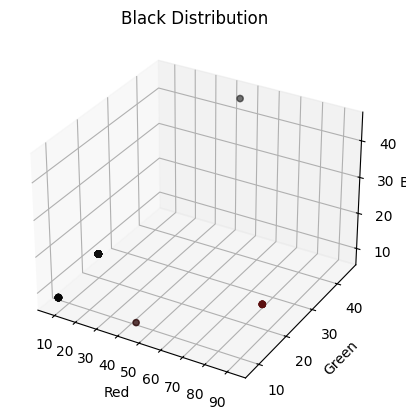

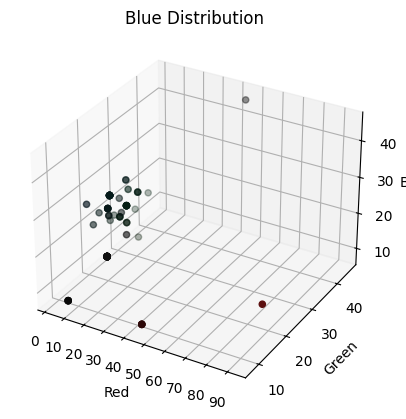

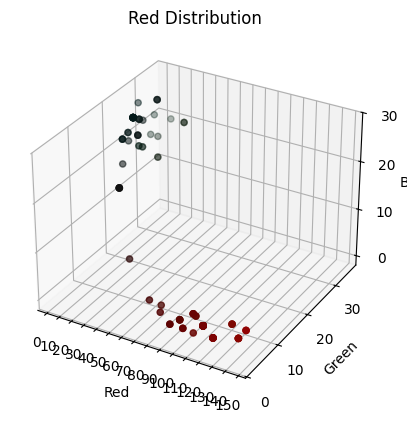

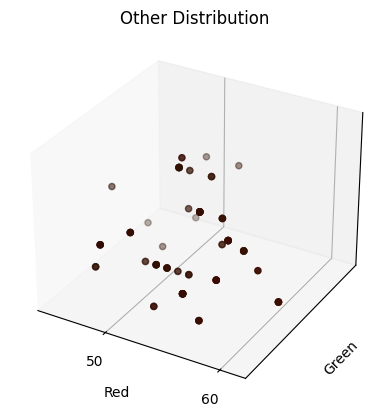

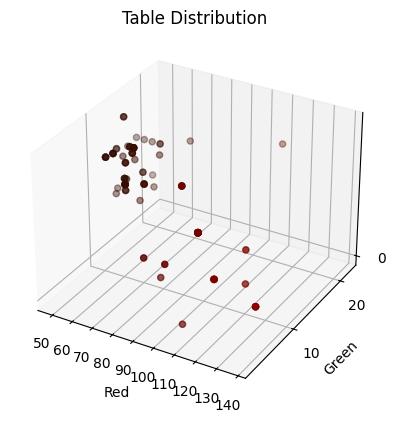

In [10]:
def plot_color_distribution(df, color_name):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    # set axis ticks to 255
    ax.set_xticks(np.arange(0, 256, 10))
    ax.set_yticks(np.arange(0, 256, 10))
    ax.set_zticks(np.arange(0, 256, 10))
    ax.scatter(df['R'], df['G'], df['B'], c=df[['R', 'G', 'B']].values / 255.0, marker='o')
    ax.set_xlabel('Red')
    ax.set_ylabel('Green')
    ax.set_zlabel('Blue')
    ax.set_title(f'{color_name} Distribution')
    plt.show()

plot_color_distribution(black_list, 'Black')
plot_color_distribution(blue_list, 'Blue')
plot_color_distribution(red_list, 'Red')
plot_color_distribution(other_list, 'Other')
plot_color_distribution(table_list, 'Table')

In [11]:
def calculate_representative_color(df):
    mean_color = df[['R', 'G', 'B']].mean()
    median_color = df[['R', 'G', 'B']].median()
    return mean_color, median_color

black_mean, black_median = calculate_representative_color(black_list)
blue_mean, blue_median = calculate_representative_color(blue_list)
red_mean, red_median = calculate_representative_color(red_list)
other_mean, other_median = calculate_representative_color(other_list)
table_mean, table_median = calculate_representative_color(table_list)

In [12]:
from scipy.spatial.distance import euclidean

# Example: Compare each color in black_list to the mean color of blue_list
target_color = blue_mean
black_distances = black_list[['R', 'G', 'B']].apply(lambda row: euclidean(row, target_color), axis=1)
print(black_distances)

0     18.356835
1      8.276074
2     48.106688
3      8.276074
4      8.276074
        ...    
95     8.276074
96    18.356835
97     8.276074
98     8.276074
99     8.276074
Length: 100, dtype: float64


In [14]:
from sklearn.cluster import KMeans

# Stack all color lists together for clustering
all_colors = pd.concat([black_list, blue_list, red_list, other_list, table_list])

# Use KMeans to find clusters
kmeans = KMeans(n_clusters=5)  # Adjust clusters based on your data
kmeans.fit(all_colors[['R', 'G', 'B']])

# Add cluster labels back to each list for analysis
all_colors['Cluster'] = kmeans.labels_

In [21]:
# Calculate mean and median for each color category
mean_colors = {
    'Black': black_list[['R', 'G', 'B']].mean(),
    'Blue': blue_list[['R', 'G', 'B']].mean(),
    'Red': red_list[['R', 'G', 'B']].mean(),
    'Other': other_list[['R', 'G', 'B']].mean(),
    'Table': table_list[['R', 'G', 'B']].mean()
}

median_colors = {
    'Black': black_list[['R', 'G', 'B']].median(),
    'Blue': blue_list[['R', 'G', 'B']].median(),
    'Red': red_list[['R', 'G', 'B']].median(),
    'Other': other_list[['R', 'G', 'B']].median(),
    'Table': table_list[['R', 'G', 'B']].median()
}

print(mean_colors)

print(median_colors)    

# Calculate distance between each cluster center and each color

print(kmeans.cluster_centers_)




{'Black': R    18.76
G    15.35
B    15.35
dtype: float64, 'Blue': R    11.50
G    22.25
B    19.03
dtype: float64, 'Red': R    60.12
G    14.51
B    12.30
dtype: float64, 'Other': R    52.12
G    14.05
B     2.46
dtype: float64, 'Table': R    69.54
G    11.25
B     2.50
dtype: float64}
{'Black': R    16.0
G    16.0
B    16.0
dtype: float64, 'Blue': R     8.0
G    24.0
B    19.0
dtype: float64, 'Red': R    32.5
G    12.0
B    12.0
dtype: float64, 'Other': R    52.0
G    14.0
B     2.0
dtype: float64, 'Table': R    55.0
G    13.0
B     3.0
dtype: float64}
[[106.0754717    4.90566038   3.86792453]
 [  7.99082569  27.33944954  22.99082569]
 [ 53.26630435  13.48369565   2.69021739]
 [ 14.58778626  14.64885496  14.64885496]
 [130.39130435   4.39130435   1.69565217]]


In [19]:
from sklearn.cluster import KMeans

# Stack all color lists together
all_colors = pd.concat([black_list, blue_list, red_list, other_list, table_list])
all_colors_np = all_colors[['R', 'G', 'B']].values

# Cluster into k groups (e.g., 5 clusters, or adjust based on your data)
kmeans = KMeans(n_clusters=5, random_state=0).fit(all_colors_np)
all_colors['Cluster'] = kmeans.labels_

# Find the centroids of these clusters
cluster_centroids = kmeans.cluster_centers_